# Uebung 2, Aufgabe 2

Kurze Beschreibung des Themas: Fußpunktanregung

Von Fußpunktanregung wird gesprochen, wenn ein System aufgrund von Laengenaenderungen seiner Uebertragungselemente zu Schwingungen angeregt wird. Diese Laengenaenderungen bewirken an seinen Federn- oder Daempferelementen eine Kraftuebertragung von der Umgebung auf's System.

Beispiel: Fahrzeugschwingungen im Auto

Aufgrund von Straßenunebenheiten, Beschleunigungsvorgaengen oder Kurvendurchfahrten wird die Karosserie des Fahrzeugs zu Schwingungen angeregt. Als Insasse wuerde man diese Vibrationen deutlich heftiger spueren, wenn die adaptiven Fahrwerke von heute nicht so ausgefeilt und fortgeschritten waeren. Also wie wuerde man bei der Auslegung eines solchen Fahrwerks vorgehen?

Zunaechst bauen wir uns ein physikalisches Ersatzmodell des Fahrwerks, an dem wir die dynamischen Eigenschaften untersuchen. Dazu reduziert man das Fahrzeug zunaechst auf einen einzigen gefederten Reifen mit einer gekoppelten Aufbaumasse, die ein Viertel der Masse der Karosserie entspricht. Daher der Name "Viertelfahrzeugmodell" (siehe Video, wobei die Modelle im Video eigentlich noch keine richtigen Viertelfahrzeugmodelle sind, sondern sogar nur halbe Viertelfahrzeugmodelle... also letztendlich Achtelfahrzeugmodelle, wenn man so will...). Dieses reduzierte Modell reicht zur ersten Einschaetzung der Dynamik aus.

Ziel dieser Untersuchungen ist es, die Oszillationen im Betrieb zu quantifizieren und die kritischen Bereiche der Frequenz zu finden, in welchem die Schwingungen am heftigsten sind. Eine typische Fahrzeugkarosserie hat in der Regel zwei solcher Resonanzbereiche, die durch Fußpunktanregung verursacht werden, wie die folgende Animation zeigt:

<video width="800" height="400" controls>
  <source src="Viertelfahrzeugmodell_Resonanzdurchfahrt.mp4" type="video/mp4">
</video>

Um  Vibrationen im Zaum zu halten, bietet sich eine starke Daempfung in den Resonanzbereichen an. Aber eine starke Daempfung verschlechtert gleichzeitig den Fahrkomfoert außerhalb der Resonanzbereiche. Wie die Pfeile im unteren Bild also zeigen: 
- die Berge im Graph werden kleiner
- die Taeler werden groeßer

<img src="Amplitudengang-Aufbaumasse.png" style="width:657px;height:317px;">

Ein intelligentes Steuergeraet fuer das Fahrwerk koennte man nun daher so programmieren: Misst die Sensorik des Fahrzeugs eine solche kritische Frequenz, wird die Daempfung entsprechend erhoeht. Ansonsten verringert. Diese Regelung geschieht ueber Hydraulikoel bzw. deren Zu- und Abfuhren. Fertig ist das adaptive Fahrwerk!

## Parameter

In [ ]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as signal

# phys. Parameter, Default-Werte, die Grenzen fuer die Slider sind auch angegeben
# Slider-Schrittweiten wie immer einfach in einer angemessenen Groeßenordnung waehlen. D.h. ungefaehr in der Groeßenordnung
# der betroffenen Groeße
J_A = 100    # inertia wrt point A      --> SLIDER, (50 bis 150), A als Index
L = 10       # length                            --> SLIDER, (5 bis 20)
c = 50      # spring constant                 --> SLIDER, (10 bis 200)
d = 0.5     # damping coefficient               --> SLIDER, (0.1 bis 5)
u_hat = 0.05       # amplitude of the seismic input      --> SLIDER, (0.05 bis 1), symbolisch machen

# Zeiteinstellung (beispielsweise)
T = 40
dt = 0.01
t = np.linspace(0, T, int(T/dt)+1)

# Berechnungsparameter, Default-Werte immer erstmal bei 0 lassen
phi_0 = 0 # initial angle       --> SLIDER, (0 bis 30) die Studis sollen das in Gradmaß einstellen...
phi_0 = np.pi*phi_0/180         # ...und dann wird das im Hintergrund in rad fuer die Berechnung umgewandelt
phi_0_dot = 0 # initial angular velocity       --> SLIDER, (0 bis 5)
x0 = (phi_0, phi_0_dot); # initial conditions

omega_0 = np.sqrt((c*L**2)/J_A) 
delta = (d*L**2)/(2*J_A)
b0 = (c*L)/J_A
b1 = (d*L)/J_A

Omega = omega_0 # angular frequency of the input --> SLIDER (bis maximal 2*omega_0 begrenzen)

In [15]:
omega_0

np.float64(7.0710678118654755)

## Dauerlauf

### Auslenkungsgraph (Dauerlauf) --> 1. Tab

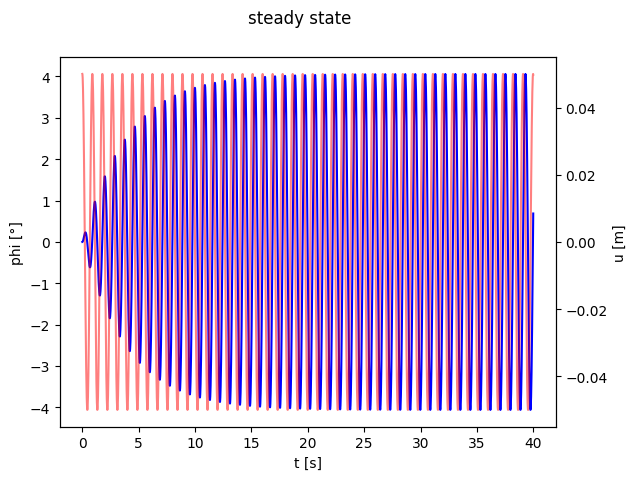

In [52]:
# state space respresentation of the steady state
def state_space_steady(x, t):
    [phi, phi_dot] = x # Zustandsvektor --> Vom Studi auszufuellen
    x_p = [phi_dot, -2*delta*phi_dot - omega_0**2*phi + b0*u_hat*np.cos(Omega*t) - b1*u_hat*Omega*np.sin(Omega*t)] # Zustands-DGL --> Vom Studi auszufuellen
    return x_p

x_sol = odeint(state_space_steady, x0, t)

# Du brauchst die erste Zeile der Loesung zum Animieren. Das ist der Winkel phi.
phi = x_sol[:,0]
phi = phi/np.pi*180 # Umrechnung von rad auf ° (ist die bessere Einheit, um sich das Ganze vorzustellen)

## Plotte die Erregung (normaler Cos) im gleichen Figure wie Loesung
fig, ax1 = plt.subplots();
ax2 = ax1.twinx();

ax1.set_ylabel('phi [°]')
ax1.set_xlabel('t [s]')
ax1.plot(t, phi, 'b');

ax2.set_ylabel('u [m]')
ax2.plot(t, u_hat*np.cos(Omega*t), 'r', alpha = 0.5); # default: alpha=1, so ist's durchsichtiger

plt.suptitle('steady state'); # Betitelung

# Vielleicht Grids hinzufuegen

## Hochlauf

### Auslenkungsgraph (Hochlauf) --> 1. Tab

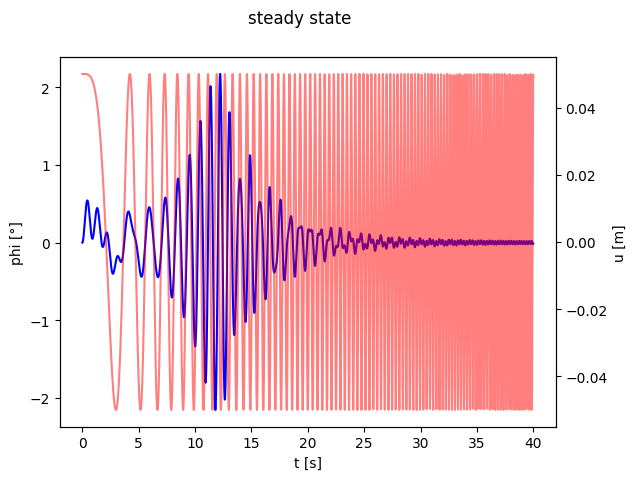

In [4]:
# Wichtig: Fuer den Hochlauf muss Omega_vec genau so groß sein wie t.
Omega_vec = np.linspace(0, 2*omega_0, t.size)

# angular acceleration of the input, Default-Wert
alpha = Omega/10 # --> SLIDER, (Omega/100 bis Omega)

# Hier wuerde ich nichts vom Studi ausfuellen lassen.
def state_space_accelerated(x, t):
    [phi, phi_dot] = x # Zustandsvektor --> Vom Studi auszufuellen
    x_p = [phi_dot, -2*delta*phi_dot - omega_0**2*phi + b0*u_hat*np.cos(0.5*alpha*t**2) - b1*u_hat*alpha*t*np.sin(0.5*alpha*t**2)] # Zustands-DGL --> Vom Studi auszufuellen
    return x_p

x_sol = odeint(state_space_accelerated, x0, t)

# Du brauchst die erste Zeile der Loesung zum Animieren. Das ist der Winkel phi.
phi = x_sol[:,0]
phi = phi/np.pi*180 # Umrechnung von rad auf ° (ist die bessere Einheit, um sich das Ganze vorzustellen)

# Du brauchst die erste Zeile der Loesung zum Animieren. Das ist die Auslenkung z.
fig, ax1 = plt.subplots();
ax2 = ax1.twinx();

ax1.set_ylabel('phi [°]')
ax1.set_xlabel('t [s]')
ax1.plot(t, phi, 'b');

ax2.set_ylabel('u [m]')
ax2.plot(t, u_hat*np.cos(0.5*alpha*t**2), 'r', alpha = 0.5); # default: alpha=1, so ist's durchsichtiger

plt.suptitle('steady state'); # Betitelung

# Grids

# Bode-Diagramme --> 2. Tab

Text(0.5, 0.98, 'Bode plots')

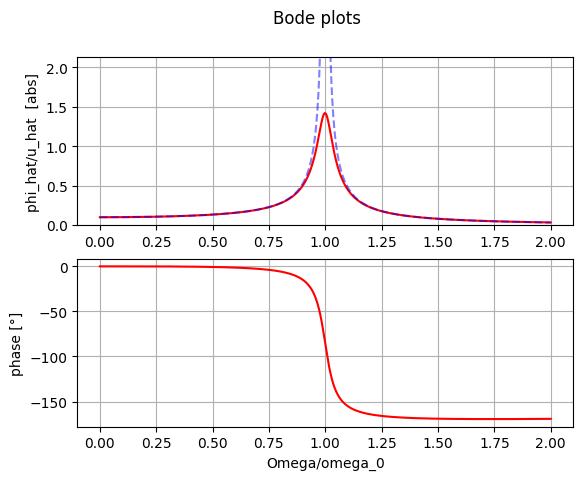

In [54]:
# transfer function
num = np.array([0, b1, b0]);
den = np.array([1, 2*delta, omega_0**2]);
G = signal.TransferFunction(num, den);

# bode-values
_, mag, phase = signal.bode(G, Omega_vec);
mag = 10**(mag/20) # Umrechnung von dB auf abs

G_undamped = signal.TransferFunction([0, 0, b0], [1, 0, omega_0**2]);
_, mag_undamped, phase_undamped = signal.bode(G_undamped, Omega_vec);
mag_undamped = 10**(mag_undamped/20)


plt.subplot(2,1,1)
plt.plot(Omega_vec/omega_0, mag, 'r');
plt.plot(Omega_vec/omega_0, mag_undamped, 'b--', alpha = 0.5);
plt.ylim(top = 1.5*max(mag))
plt.ylim(bottom = 0)
plt.ylabel('phi_hat/u_hat  [abs]') #  z_Hut / epsilon --> symbolisch
plt.grid()

plt.subplot(2,1,2)
plt.plot(Omega_vec/omega_0, phase, 'r');
plt.ylabel('phase [°]') # kannst du daraus phi_z mit Index z machen?
plt.xlabel('Omega/omega_0') # groß Omega / klein omega_0 --> symbolisch
plt.grid()

plt.suptitle('Bode plots')